# Evaluation and SHAP analysis 🤔

In [1]:
# 0.0 
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
import shap

# Load in the data
df = pd.read_csv('../processed/training_data.csv')
test_df = pd.read_csv('../processed/test_data.csv')

X_test = test_df

test_df.head()

,Id,MSSubClass,LotFrontage,LotArea,Alley,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1461,20,80.0,11622,0,5,6,1961,1961,0.0,...,False,False,False,False,True,False,False,False,True,False
1,1462,20,81.0,14267,0,6,6,1958,1958,108.0,...,False,False,False,False,True,False,False,False,True,False
2,1463,60,74.0,13830,0,5,5,1997,1998,0.0,...,False,False,False,False,True,False,False,False,True,False
3,1464,60,78.0,9978,0,6,6,1998,1998,20.0,...,False,False,False,False,True,False,False,False,True,False
4,1465,120,43.0,5005,0,8,5,1992,1992,0.0,...,False,False,False,False,True,False,False,False,True,False


In [2]:
# Load in the model
with open('../models/trained_xgb.pkl', 'rb') as f:
    model = pickle.load(f)

In [3]:
y_pred = model.predict(X_test)

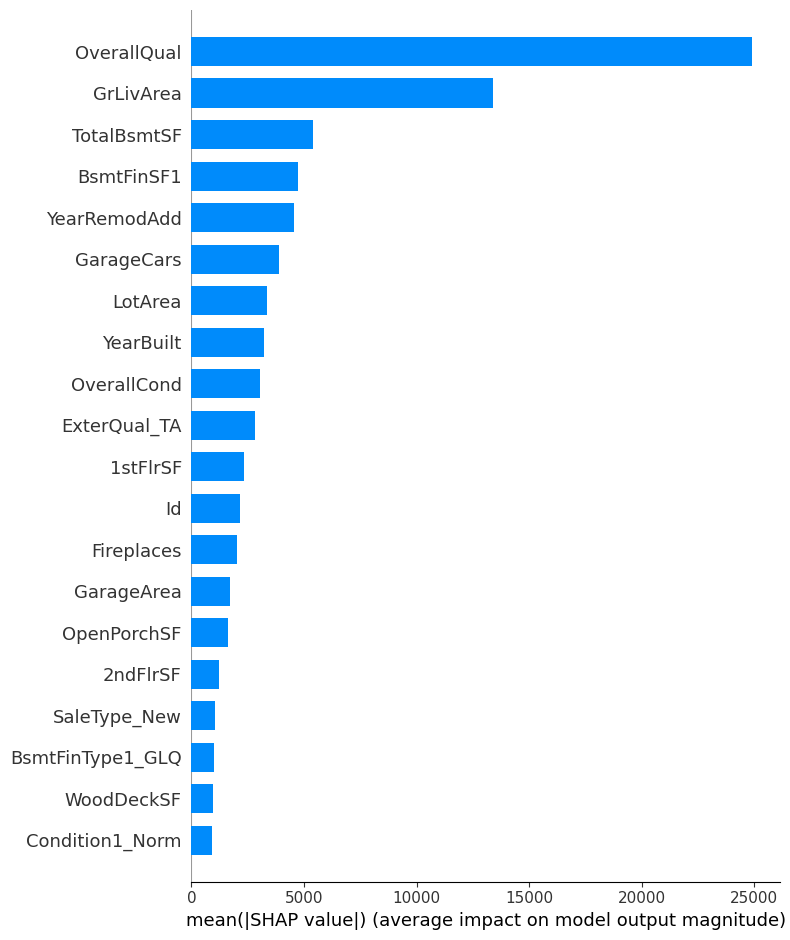

<Figure size 640x480 with 0 Axes>

In [9]:
# initialise shap
shap.initjs()

# Shap anaylsis
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_type = "bar")
plt.savefig('../plots/shap_summary.png')
plt.show()

In [13]:
# Individual prediction
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])
plt.savefig('../plots/forceplot.png, dpi=300, bbox_inches='tight')

SyntaxError: unterminated string literal (detected at line 3) (1991812469.py, line 3)

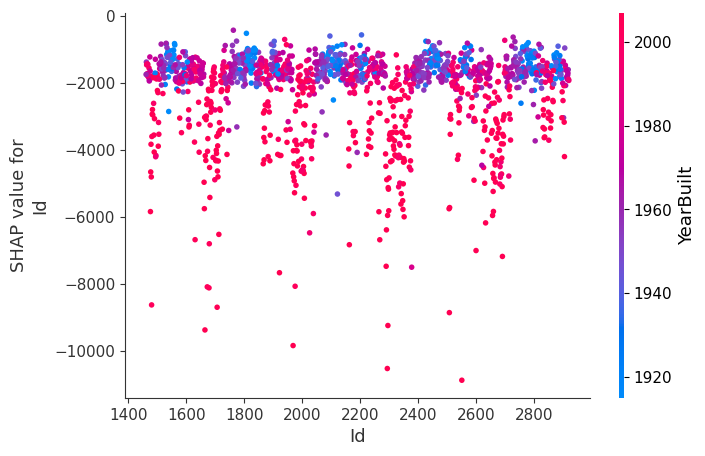

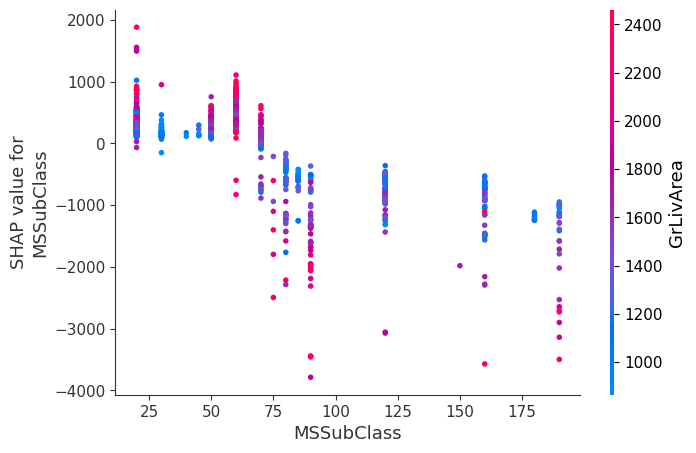

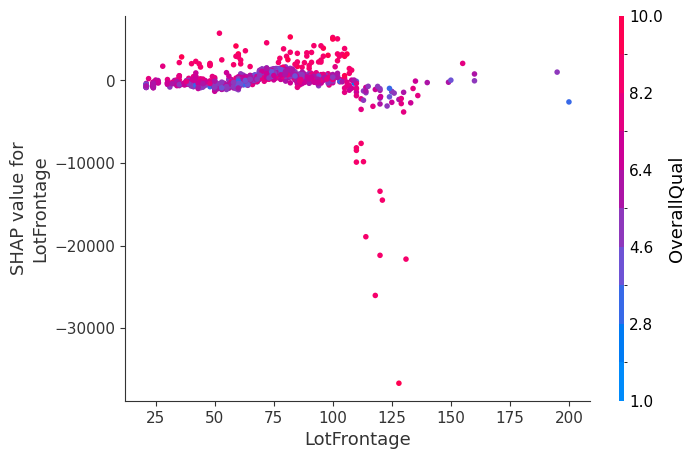

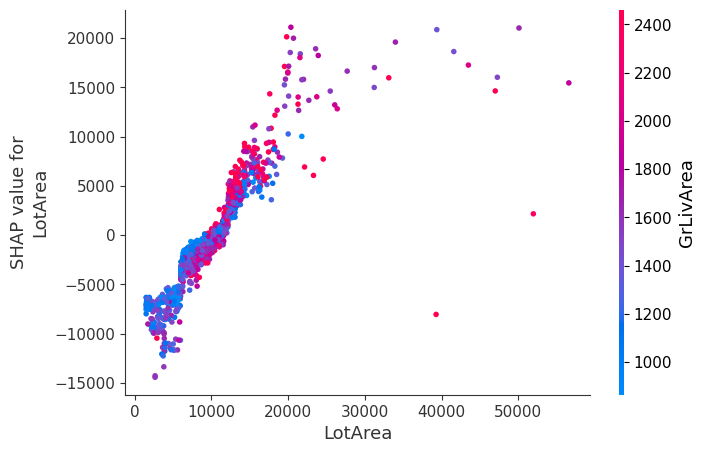

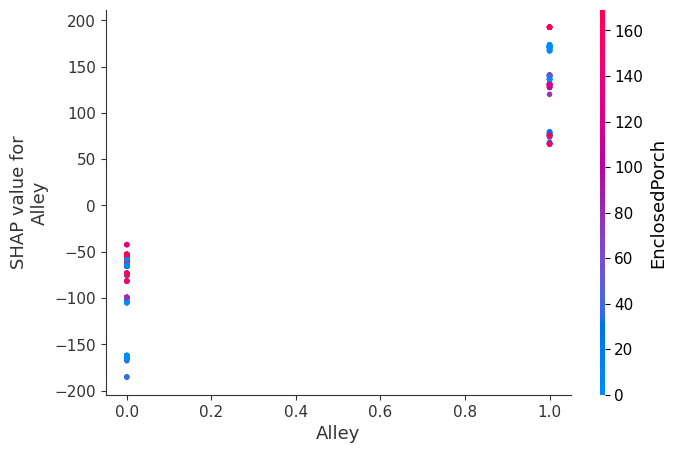

In [11]:
for feature in X_test.columns[:5]:  # Top 5 features
    shap.dependence_plot(feature, shap_values, X_test, show=False)
    plt.savefig(f'../plots/shap_dependence_{feature}.png', dpi=300, bbox_inches='tight')
    plt.show()
